# Hospital 30-Day Readmission Prediction

## Problem Statement

The objective of this project is to predict whether a patient is likely to be readmitted to the hospital within 30 days.

A Logistic Regression model with L2 regularization is used to perform binary classification.

### Key Objectives
- Prepare and clean patient data
- Explore important patterns in the dataset
- Engineer the binary readmission target
- Preprocess numerical and categorical features
- Train Logistic Regression with L2 regularization
- Evaluate the model using Accuracy, Precision, Recall, F1-score, and ROC-AUC
- Analyze the clinical cost of false negatives and false positives

In [62]:
# Import libraries for data manipulation and numerical operations
import pandas as pd
import numpy as np

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import functions for splitting the dataset
from sklearn.model_selection import train_test_split

# Import tools for preprocessing different feature types
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

## 2. Dataset Loading

The dataset contains hospital encounter records that can be used to study 30-day readmission.

The dataset is loaded into a Pandas DataFrame for further analysis and preprocessing.

In [63]:
# Load the hospital readmission dataset
df = pd.read_csv("/content/diabetic_data.csv")

# Display the dataset dimensions
print("Dataset Shape:", df.shape)

# Display the first five records
df.head()

Dataset Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 3. Data Understanding

Before preprocessing, the dataset structure, columns, and target distribution are examined.


In [64]:
# Display information about columns, data types, and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [65]:
# Display all column names
df.columns.tolist()

['encounter_id',
 'patient_nbr',
 'race',
 'gender',
 'age',
 'weight',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'payer_code',
 'medical_specialty',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'diag_1',
 'diag_2',
 'diag_3',
 'number_diagnoses',
 'max_glu_serum',
 'A1Cresult',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed',
 'readmitted']

In [67]:
# Check the distribution of the original readmission categories
df["readmitted"].value_counts()

# The original `readmitted` variable contains multiple categories.
# For this project, the problem is converted into binary classification:
# - `1` → Readmitted within 30 days (`<30`)
# - `0` → Not readmitted within 30 days (`>30` or `NO`)

,count
readmitted,
NO,54864
>30,35545
<30,11357


## 4. Data Preprocessing

The dataset represents missing values using `?`.

These values are converted to `NaN` so that missing data can be identified and handled consistently.


In [68]:
# Replace '?' values with NaN and preserve appropriate data types
df = df.replace("?", np.nan).infer_objects(copy=False)

print("Missing values replaced successfully.")

Missing values replaced successfully.


In [69]:
# Calculate the number of missing values in each column
missing_values = df.isnull().sum()

# Display columns with the highest number of missing values
missing_values.sort_values(ascending=False).head(20)

,0
weight,98569
max_glu_serum,96420
A1Cresult,84748
medical_specialty,49949
payer_code,40256
race,2273
diag_3,1423
diag_2,358
diag_1,21
patient_nbr,0


In [70]:
# Create binary target variable
# 1 = readmitted within 30 days
# 0 = not readmitted within 30 days

df["target"] = (df["readmitted"] == "<30").astype(int)

# Display target distribution
df["target"].value_counts()

,count
target,
0,90409
1,11357


In [71]:
# Remove the original multi-class readmission column
# because the new binary 'target' column will be used for prediction
df = df.drop(columns=["readmitted"])

print("Original readmitted column removed.")

Original readmitted column removed.


In [73]:
### Removing Identifier Columns
# encounter_id and patient_nbr are identifiers rather than meaningful predictive features.
# They are removed to prevent the model from learning patterns based on patient or encounter IDs.

df = df.drop(columns=["encounter_id", "patient_nbr"])

print("Identifier columns removed.")

Identifier columns removed.


In [74]:
### Handling Highly Missing Features
# Several columns contain a very high percentage of missing values.
# For this project, features with extremely high missingness are removed instead of applying extensive imputation.

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False).head(20)

,0
weight,96.858479
max_glu_serum,94.746772
A1Cresult,83.277322
medical_specialty,49.082208
payer_code,39.557416
race,2.233555
diag_3,1.398306
diag_2,0.351787
diag_1,0.020636
time_in_hospital,0.000000


In [75]:
# Remove features with extremely high missing-value percentages
df = df.drop(columns=[
    "weight",
    "max_glu_serum",
    "A1Cresult",
    "medical_specialty",
    "payer_code"
])

print("High-missing columns removed.")

High-missing columns removed.


In [76]:
# Display the shape of the cleaned dataset
print("Cleaned Dataset Shape:", df.shape)

# Display the first five rows
df.head()

Cleaned Dataset Shape: (101766, 43)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,target
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,0
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,0


## 5. Exploratory Data Analysis

### 30-Day Readmission Distribution

The target distribution is visualized to understand the balance between patients who were and were not readmitted within 30 days.

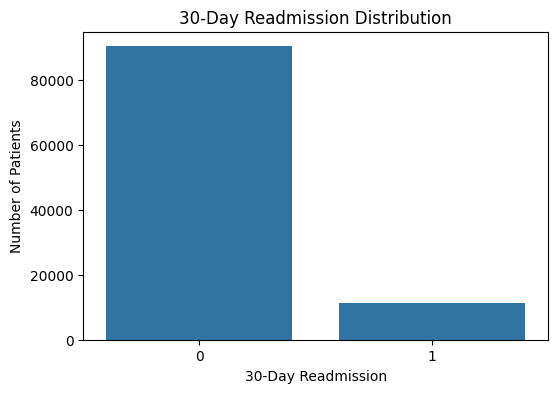

In [77]:
# Visualize the distribution of the target variable
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="target")

plt.title("30-Day Readmission Distribution")
plt.xlabel("30-Day Readmission")
plt.ylabel("Number of Patients")

plt.show()

### EDA Insight

The dataset contains substantially more patients without a 30-day readmission than patients readmitted within 30 days.

This class imbalance means that accuracy alone is not sufficient for evaluating the model.

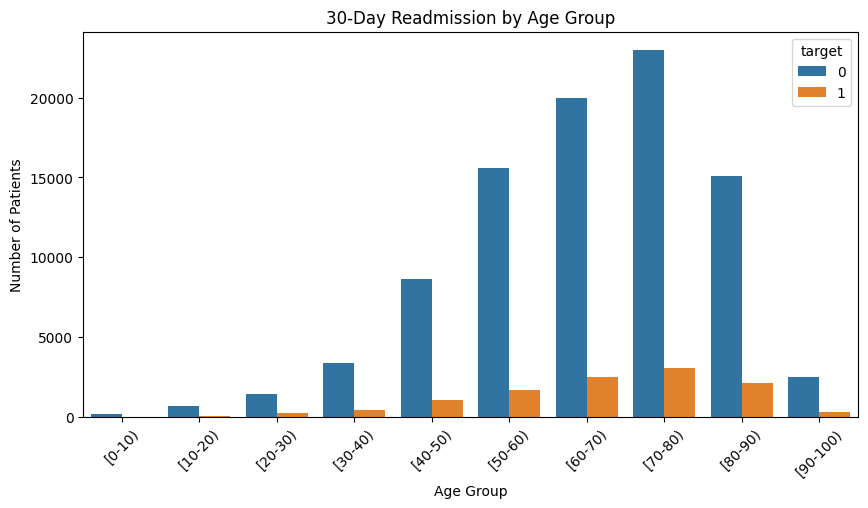

In [79]:
# Visualize 30-day readmission across age groups
plt.figure(figsize=(10, 5))

sns.countplot(data=df, x="age", hue="target")

plt.title("30-Day Readmission by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")

plt.xticks(rotation=45)

plt.show()

### EDA Insight

Patients are distributed across multiple age groups, with a large proportion of records belonging to older age categories.

30-day readmissions are observed across several age groups, making age a potentially useful predictive feature.

### Correlation Analysis

A correlation heatmap is used to examine relationships among numerical features.

Correlation values range from -1 to +1:

- Positive values indicate a positive relationship
- Negative values indicate a negative relationship
- Values near 0 indicate a weak linear relationship

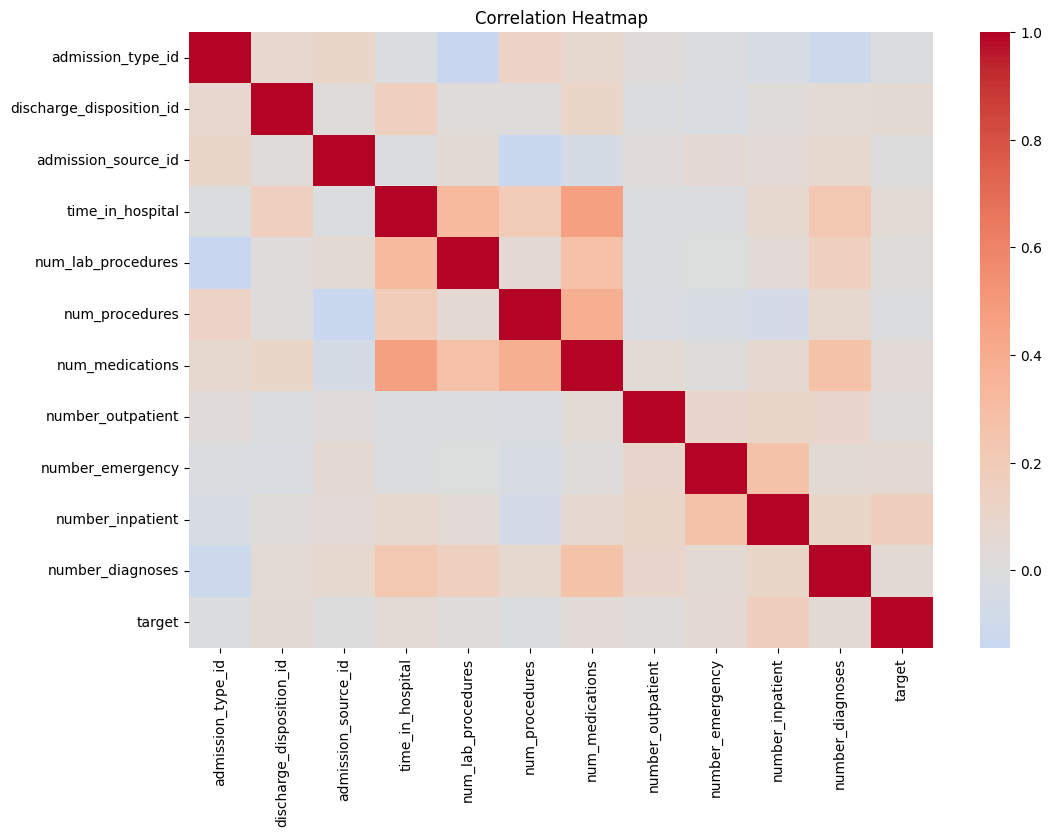

In [80]:
# Select numerical columns for correlation analysis
numeric_cols = df.select_dtypes(include=np.number).columns

# Create a correlation heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    df[numeric_cols].corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

## 6. Feature Selection

The model uses a selected set of numerical and categorical features.

Numerical features capture quantities such as hospital stay, procedures, medications, and previous hospital visits.

Categorical features capture patient and admission characteristics.

In [81]:
# Define numerical features
numeric_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

# Define categorical features
categorical_features = [
    "race",
    "gender",
    "age",
    "admission_type_id",
    "change",
    "diabetesMed"
]

In [82]:
# Combine numerical and categorical features
features = numeric_features + categorical_features

# Create input features
X = df[features]

# Create target variable
y = df["target"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (101766, 14)
y Shape: (101766,)


## 7. Train-Test Split

The dataset is divided into:

- 80% training data
- 20% testing data

Stratification is used to maintain a similar proportion of the two target classes in both datasets.

In [83]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (81412, 14)
Testing Data: (20354, 14)


## 8. Feature Preprocessing

Numerical and categorical features require different preprocessing methods.

- Numerical features → StandardScaler
- Categorical features → OneHotEncoder

Standardization is useful for Logistic Regression because it puts numerical features on a comparable scale.

One-hot encoding converts categorical values into numerical binary features.

In [84]:
# Create preprocessing steps for numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [85]:
# Fit the preprocessor only on the training data
# and transform the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the test data using the already fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Training data after preprocessing:", X_train_processed.shape)
print("Testing data after preprocessing:", X_test_processed.shape)

Training data after preprocessing: (81412, 39)
Testing data after preprocessing: (20354, 39)


## 9. Baseline Logistic Regression

An unregularized Logistic Regression model is first trained as a baseline.

This provides a reference point for comparing the effect of L2 regularization.

In [86]:
# Create a baseline Logistic Regression model without regularization
model_no_l2 = LogisticRegression(
    penalty=None,
    max_iter=1000
)

In [90]:
# Train the baseline Logistic Regression model
model_no_l2.fit(X_train_processed, y_train)

print("Baseline Logistic Regression model trained successfully.")

Baseline Logistic Regression model trained successfully.


In [91]:
# Generate class predictions for the test data
y_pred_no_l2 = model_no_l2.predict(X_test_processed)

# Generate probabilities for the positive class
y_prob_no_l2 = model_no_l2.predict_proba(X_test_processed)[:, 1]

# Display a few predictions and probabilities
print("Predictions:", y_pred_no_l2[:10])
print("Probabilities:", y_prob_no_l2[:10])

Predictions: [0 0 0 0 0 0 0 0 0 0]
Probabilities: [0.13725618 0.09606588 0.11342731 0.10860984 0.13412286 0.06372064
 0.07741715 0.07485553 0.26744732 0.12436093]


## 10. Logistic Regression with L2 Regularization

L2 regularization is applied to control the magnitude of model coefficients and reduce the risk of overfitting.

The regularized model is then evaluated using the same metrics as the baseline model.

In [92]:
# Create Logistic Regression model with L2 regularization
model_l2 = LogisticRegression(
    penalty="l2",
    max_iter=1000
)

In [53]:
model_l2.fit(X_train_processed, y_train)

LogisticRegression(max_iter=1000)

## 11. Model Evaluation

The L2 Logistic Regression model is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Because the target classes are imbalanced, Recall and ROC-AUC are particularly important alongside accuracy.

In [51]:
print("Accuracy :", accuracy_score(y_test, y_pred_no_l2))
print("Precision:", precision_score(y_test, y_pred_no_l2, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_no_l2, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred_no_l2, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_no_l2))

Accuracy : 0.8885231404146605
Precision: 0.5161290322580645
Recall   : 0.014090708938793483
F1 Score : 0.02743249035576511
ROC-AUC  : 0.6405680538632798


In [54]:
# Train the Logistic Regression model using the preprocessed training data
model_l2.fit(X_train_processed, y_train)

print("L2 Logistic Regression model trained successfully.")

L2 Logistic Regression model trained successfully.


In [55]:
# Predict the class labels for the test data
y_pred_l2 = model_l2.predict(X_test_processed)

# Predict the probability of 30-day readmission (class 1)
y_prob_l2 = model_l2.predict_proba(X_test_processed)[:, 1]

# Display the first 10 predictions and probabilities
print("Predictions:", y_pred_l2[:10])
print("Probabilities:", y_prob_l2[:10])

Predictions: [0 0 0 0 0 0 0 0 0 0]
Probabilities: [0.13692622 0.09543363 0.11380847 0.10868906 0.1314749  0.06310689
 0.07681361 0.07464036 0.26786896 0.12465059]


In [56]:
# Calculate evaluation metrics for the L2 Logistic Regression model
accuracy_l2 = accuracy_score(y_test, y_pred_l2)
precision_l2 = precision_score(y_test, y_pred_l2)
recall_l2 = recall_score(y_test, y_pred_l2)
f1_l2 = f1_score(y_test, y_pred_l2)
roc_auc_l2 = roc_auc_score(y_test, y_prob_l2)

# Display the results
print("Accuracy :", accuracy_l2)
print("Precision:", precision_l2)
print("Recall   :", recall_l2)
print("F1 Score :", f1_l2)
print("ROC-AUC  :", roc_auc_l2)

Accuracy : 0.8885231404146605
Precision: 0.5161290322580645
Recall   : 0.014090708938793483
F1 Score : 0.02743249035576511
ROC-AUC  : 0.6406983790897363


In [58]:
# Create the confusion matrix for the L2 model
cm = confusion_matrix(y_test, y_pred_l2)

# Display the confusion matrix values
print(cm)

[[18053    30]
 [ 2239    32]]


## 13. ROC Curve and ROC-AUC

The ROC curve evaluates the model's ability to distinguish between patients who are readmitted within 30 days and those who are not across different classification thresholds.

ROC-AUC summarizes this discrimination ability:

- AUC = 0.5 → approximately random classification
- AUC = 1.0 → perfect discrimination

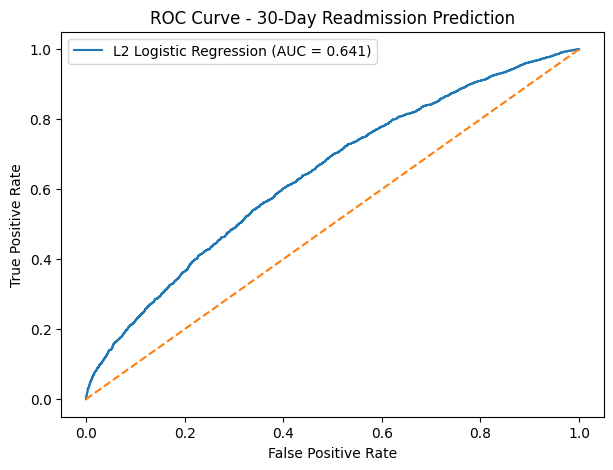

In [59]:
# Calculate False Positive Rate and True Positive Rate at different thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_prob_l2)

# Plot the ROC curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"L2 Logistic Regression (AUC = {roc_auc_l2:.3f})")

# Plot the random classifier reference line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - 30-Day Readmission Prediction")
plt.legend()
plt.show()

## 14. Baseline vs L2 Model Comparison

The baseline Logistic Regression and L2-regularized Logistic Regression models are compared using the same evaluation metrics.

In [93]:
# Store evaluation results of both Logistic Regression models
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "No L2": [
        accuracy_score(y_test, y_pred_no_l2),
        precision_score(y_test, y_pred_no_l2),
        recall_score(y_test, y_pred_no_l2),
        f1_score(y_test, y_pred_no_l2),
        roc_auc_score(y_test, y_prob_no_l2)
    ],
    "L2": [
        accuracy_l2,
        precision_l2,
        recall_l2,
        f1_l2,
        roc_auc_l2
    ]
})

# Display the comparison
results

,Metric,No L2,L2
0,Accuracy,0.888523,0.888523
1,Precision,0.516129,0.516129
2,Recall,0.014091,0.014091
3,F1 Score,0.027432,0.027432
4,ROC-AUC,0.640568,0.640698


## 15. Clinical Cost Considerations

The two types of classification errors have different implications.

### False Negative

A false negative occurs when a patient who is actually readmitted within 30 days is predicted as not being readmitted.

This may cause a potentially important patient to be missed for additional follow-up or intervention.

### False Positive

A false positive occurs when a patient who is not readmitted within 30 days is predicted as being at risk.

This may result in additional follow-up, monitoring, or use of healthcare resources.

### Key Consideration

For a hospital readmission prediction system, the appropriate classification threshold should consider the relative costs of false negatives and false positives rather than relying only on the default 0.5 threshold.

## 16. Conclusion

A Logistic Regression model with L2 regularization was developed to predict 30-day hospital readmission.

The workflow included data cleaning, exploratory analysis, feature selection, numerical scaling, categorical encoding, model training, and evaluation.

The L2 Logistic Regression model achieved an ROC-AUC of approximately 0.641 on the test set.

The results also highlight the effect of class imbalance: although the model achieved high overall accuracy, its recall for the 30-day readmission class was low at the default 0.5 classification threshold.

Therefore, evaluation of readmission prediction should consider metrics beyond accuracy, particularly Recall and ROC-AUC, while also accounting for the different clinical implications of false negatives and false positives.